In [ ]:
# Notebook ini berfungsi untuk melakukan pembersihan data, menangani nilai kosong, 
# serta mengeksplorasi tren awal penyewaan melalui visualisasi data.

# Tahap ini memastikan dataset sudah melalui proses preprocessing dan 
# rekayasa fitur yang tepat sebelum diolah oleh berbagai model data mining.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/hour.csv')

# Preprocessing singkat: Ubah dteday ke format datetime
df['dteday'] = pd.to_datetime(df['dteday'])

print("--- Cuplikan Data ---")
display(df.head())

print("\n--- Info Dataset ---")
df.info()

--- Cuplikan Data ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  

In [8]:
# Cek Missing Values
print("Missing Values:\n", df.isnull().sum())

# Cek Duplikat
print("\nJumlah Duplikat:", df.duplicated().sum())

# Statistik Deskriptif (Penting untuk melihat anomali/outlier)
display(df.describe())

Missing Values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah Duplikat: 0


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


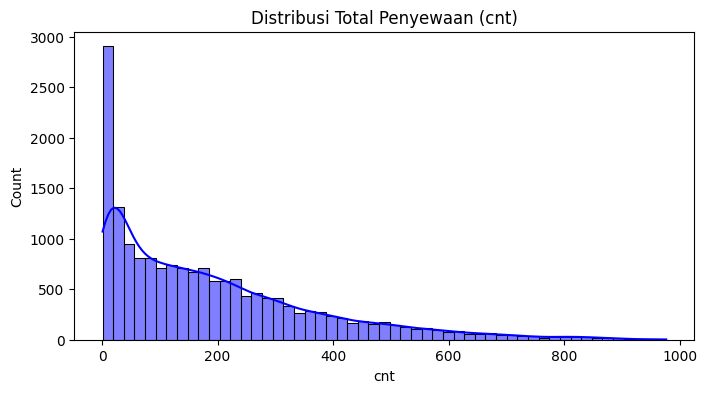

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['cnt'], kde=True, color='blue')
plt.title("Distribusi Total Penyewaan (cnt)")
plt.show()

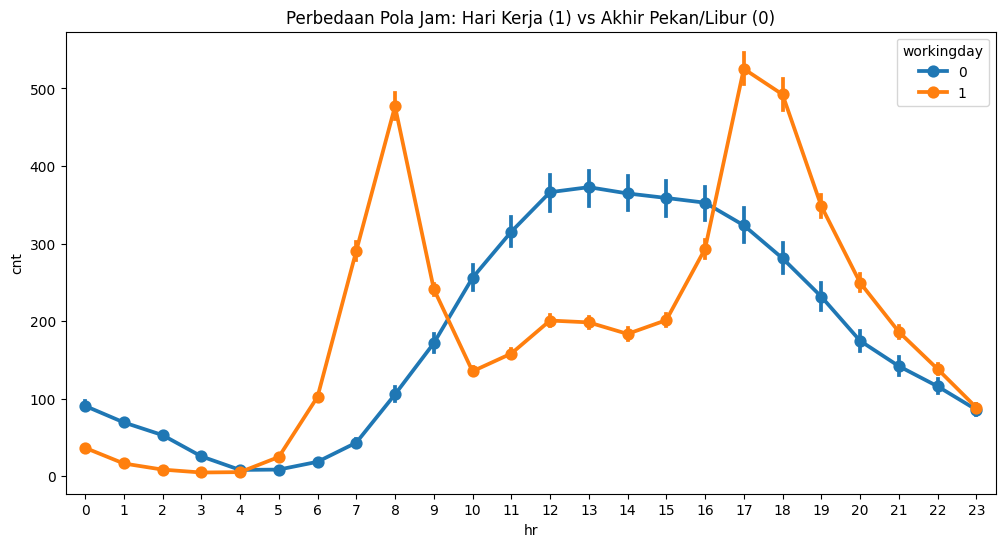

In [10]:
plt.figure(figsize=(12, 6))
sns.pointplot(data=df, x='hr', y='cnt', hue='workingday')
plt.title("Perbedaan Pola Jam: Hari Kerja (1) vs Akhir Pekan/Libur (0)")
plt.show()

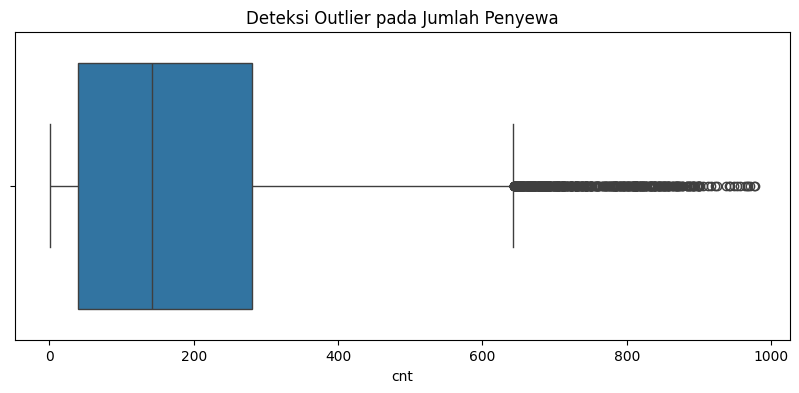

In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['cnt'])
plt.title("Deteksi Outlier pada Jumlah Penyewa")
plt.show()

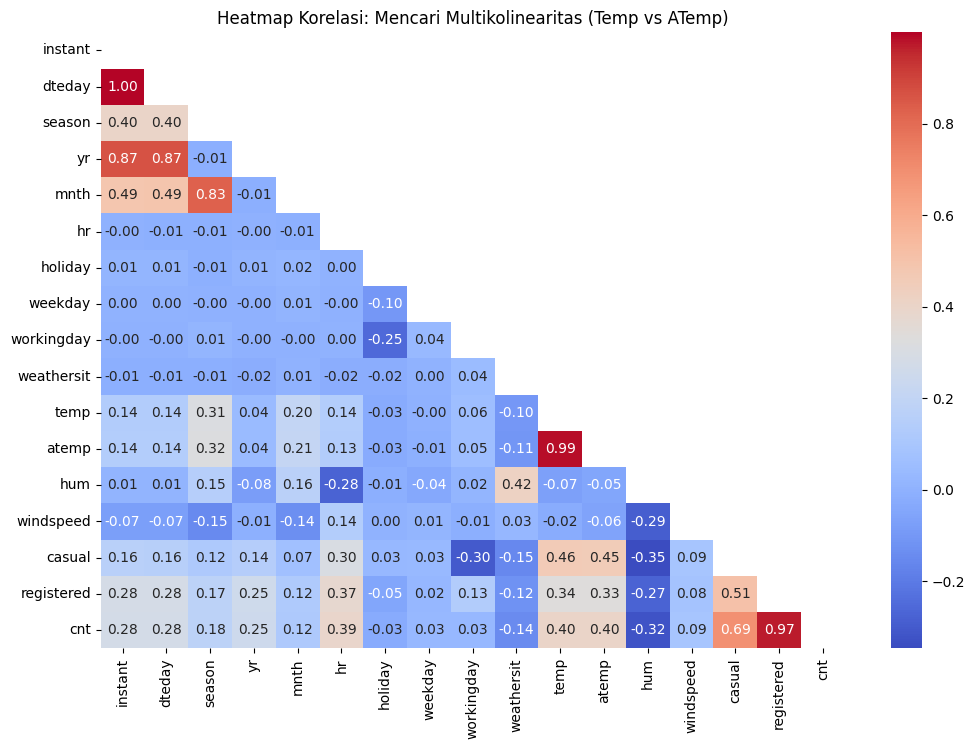

In [3]:
# -----------------------------------------------------------------
# PHASE 1: EDA UNTUK REGRESI (Melihat Hubungan Linear)
# -----------------------------------------------------------------
## Fokus: Korelasi variabel cuaca terhadap total penyewa (cnt)

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Heatmap Korelasi: Mencari Multikolinearitas (Temp vs ATemp)")
plt.show()

# Insight: Jika temp dan atemp korelasinya > 0.9, pilih satu saja untuk Regresi.

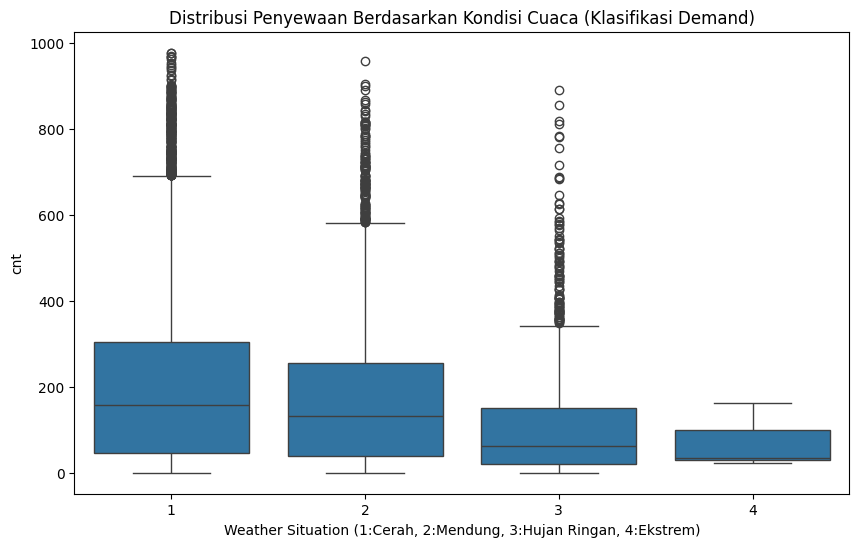

In [4]:
# -----------------------------------------------------------------
# PHASE 2: EDA UNTUK KLASIFIKASI (Melihat Pemisahan Kelas)
# -----------------------------------------------------------------
## Fokus: Distribusi penyewaan berdasarkan kondisi cuaca atau jam kerja

plt.figure(figsize=(10, 6))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Distribusi Penyewaan Berdasarkan Kondisi Cuaca (Klasifikasi Demand)")
plt.xlabel("Weather Situation (1:Cerah, 2:Mendung, 3:Hujan Ringan, 4:Ekstrem)")
plt.show()

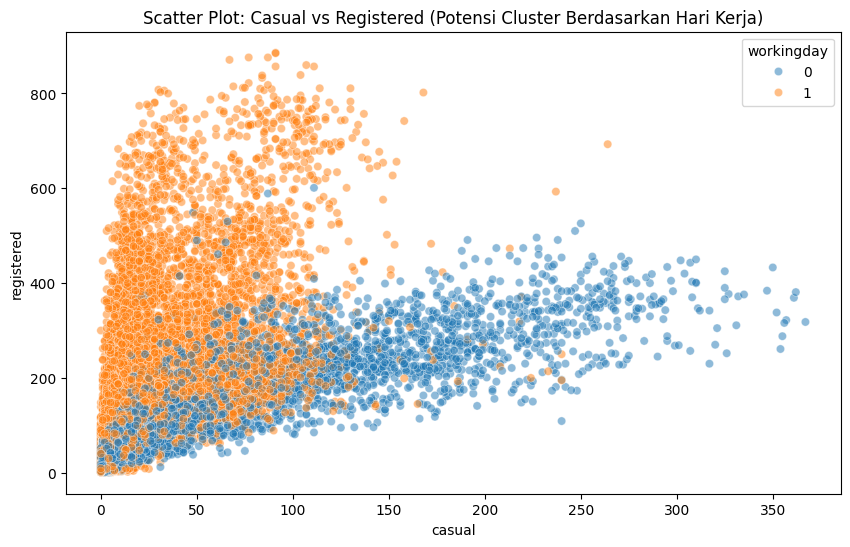

In [5]:
# -----------------------------------------------------------------
# PHASE 3: EDA UNTUK CLUSTERING (Segmentasi Pengguna)
# -----------------------------------------------------------------
## Fokus: Perbedaan pola antara pengguna Casual vs Registered

plt.figure(figsize=(10, 6))
sns.scatterplot(x='casual', y='registered', hue='workingday', data=df, alpha=0.5)
plt.title("Scatter Plot: Casual vs Registered (Potensi Cluster Berdasarkan Hari Kerja)")
plt.show()

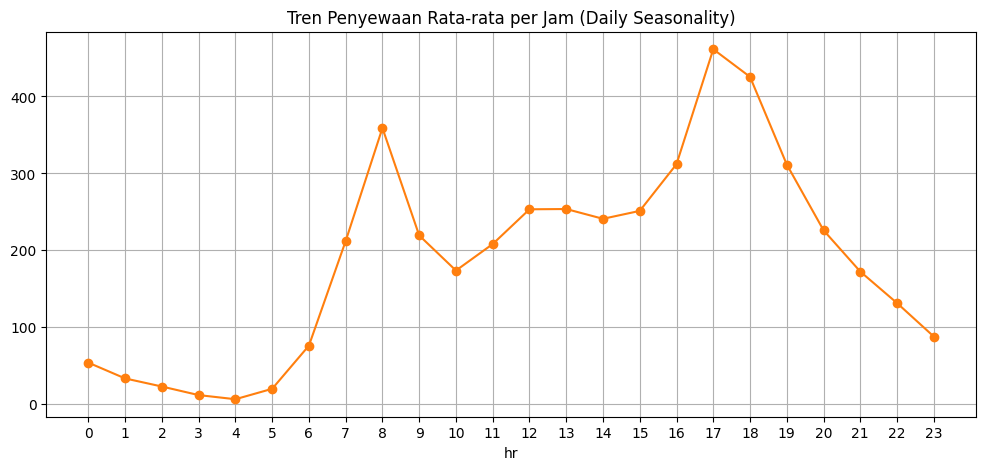

In [6]:
# -----------------------------------------------------------------
# PHASE 4: EDA UNTUK TIME FORECASTING (Analisis Deret Waktu)
# -----------------------------------------------------------------
## Fokus: Tren harian dan musiman

# Melihat rata-rata penyewaan per jam dalam satu hari
hourly_trend = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12, 5))
hourly_trend.plot(kind='line', marker='o', color='tab:orange')
plt.title("Tren Penyewaan Rata-rata per Jam (Daily Seasonality)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

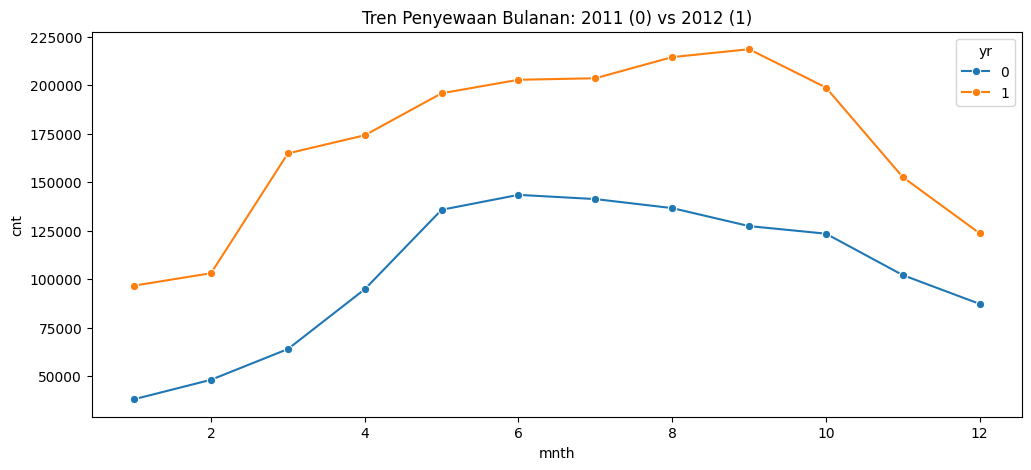

In [7]:
# Melihat tren jangka panjang (Bulanan)
monthly_trend = df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(x='mnth', y='cnt', hue='yr', data=monthly_trend, marker='o')
plt.title("Tren Penyewaan Bulanan: 2011 (0) vs 2012 (1)")
plt.show()